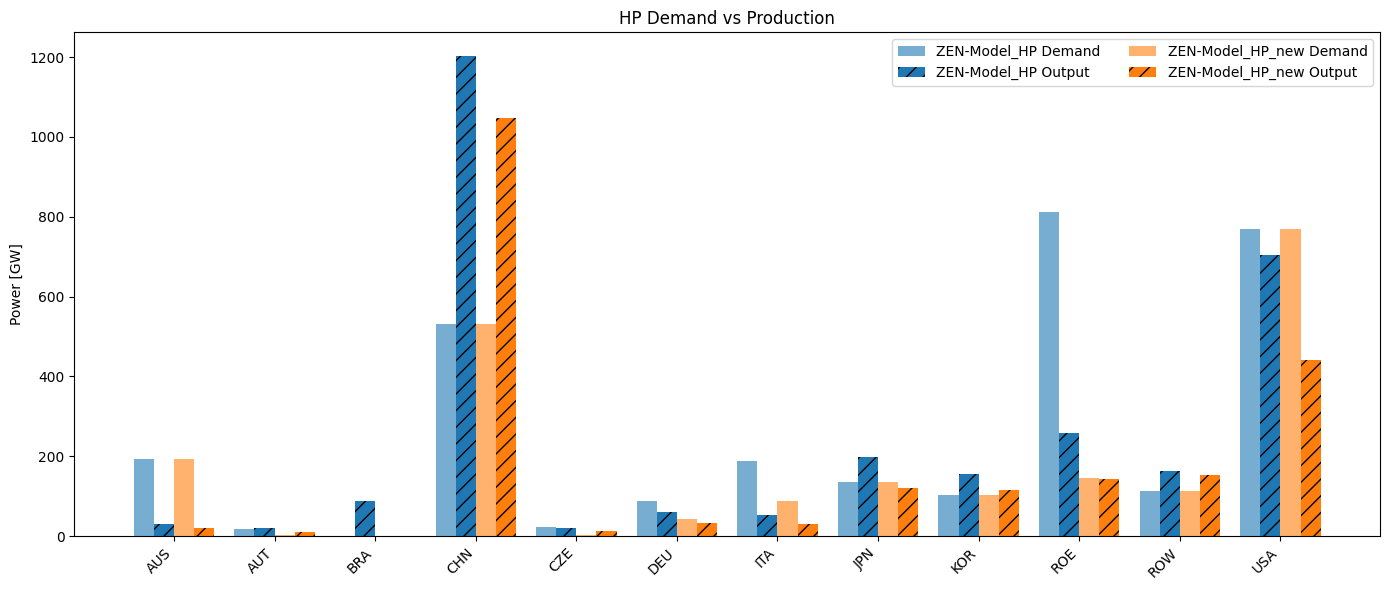

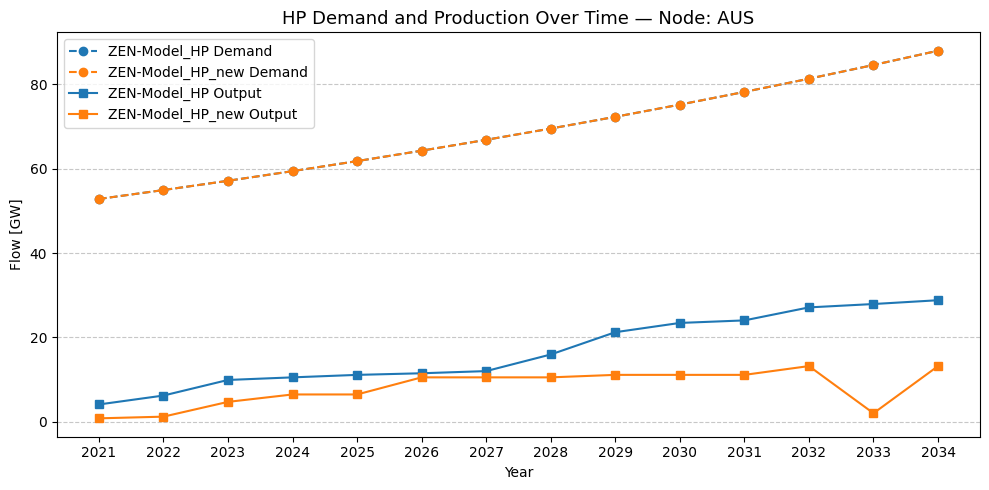

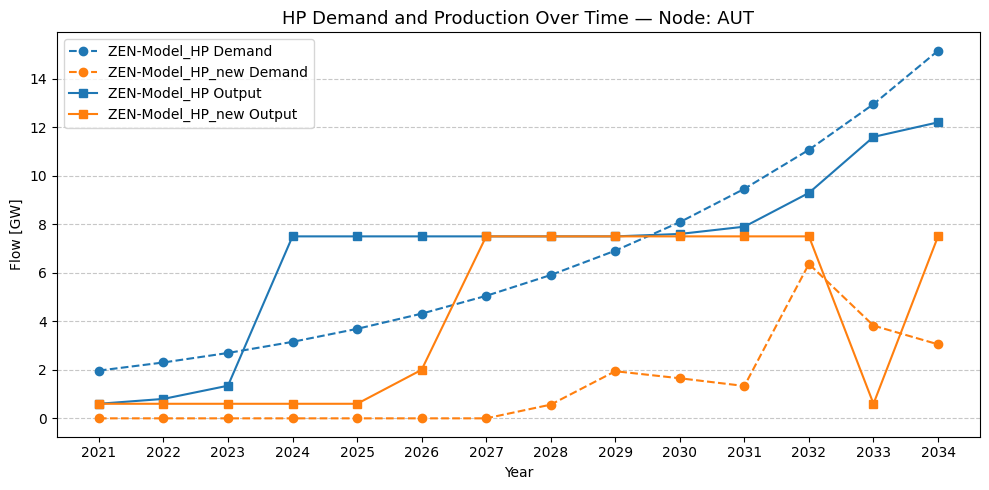

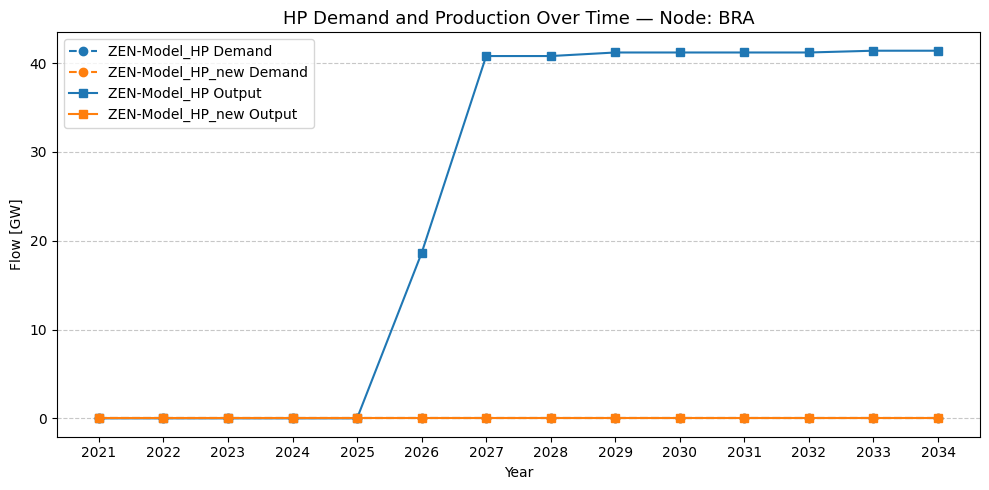

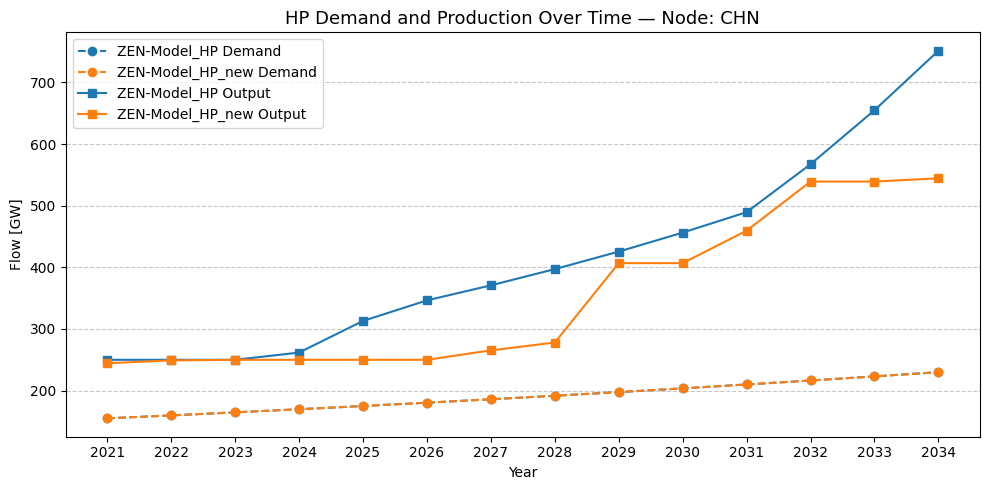

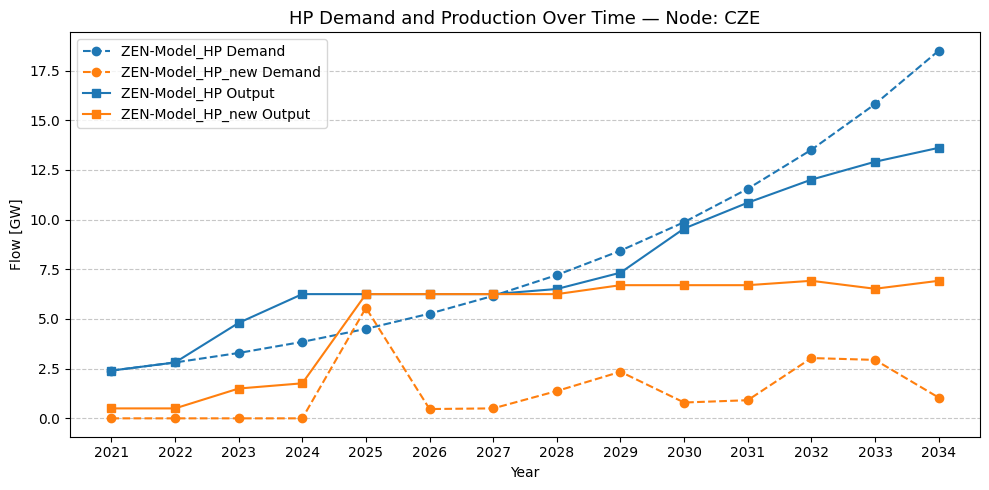

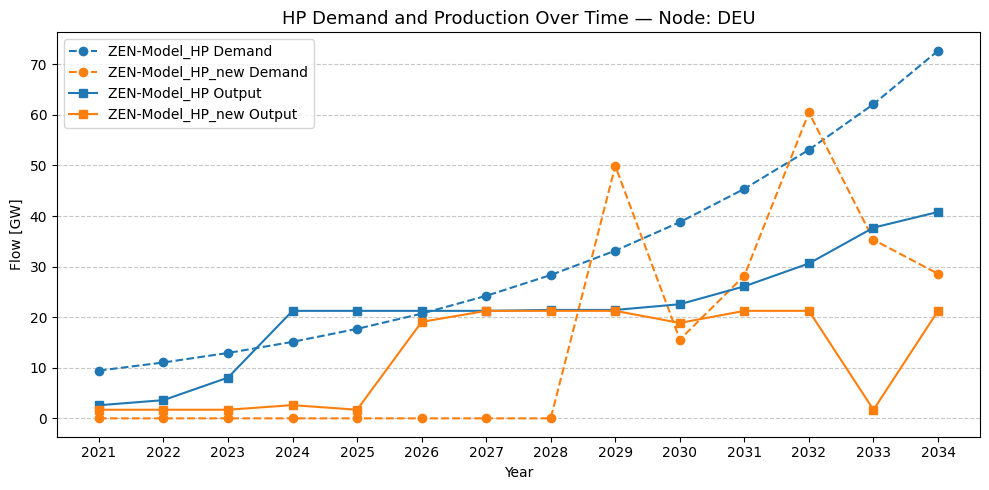

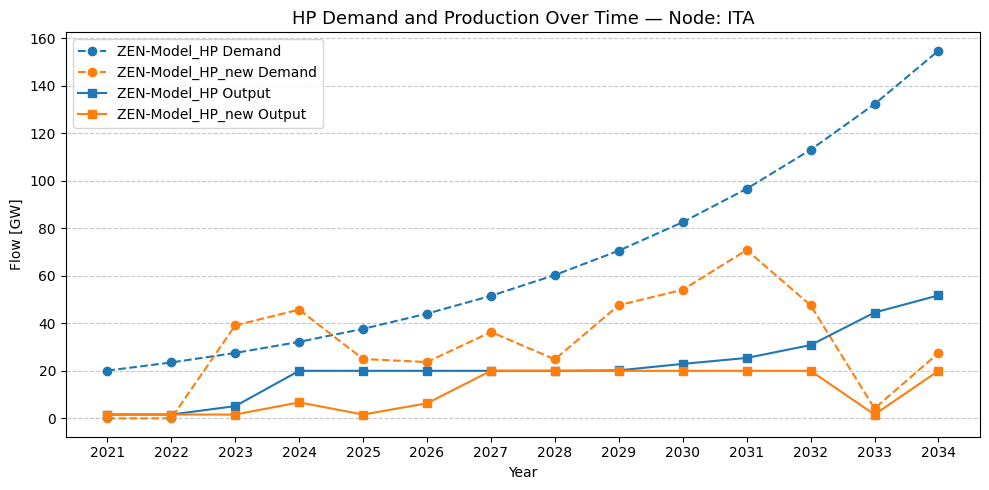

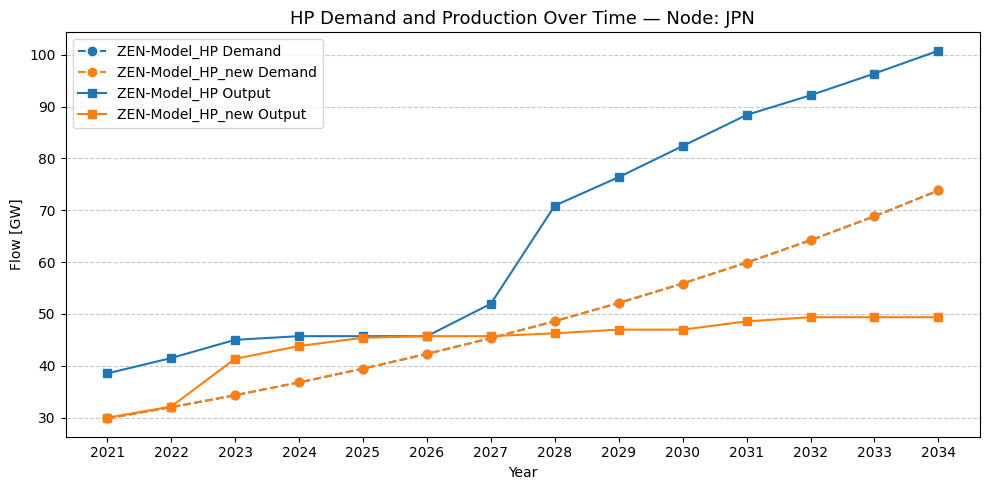

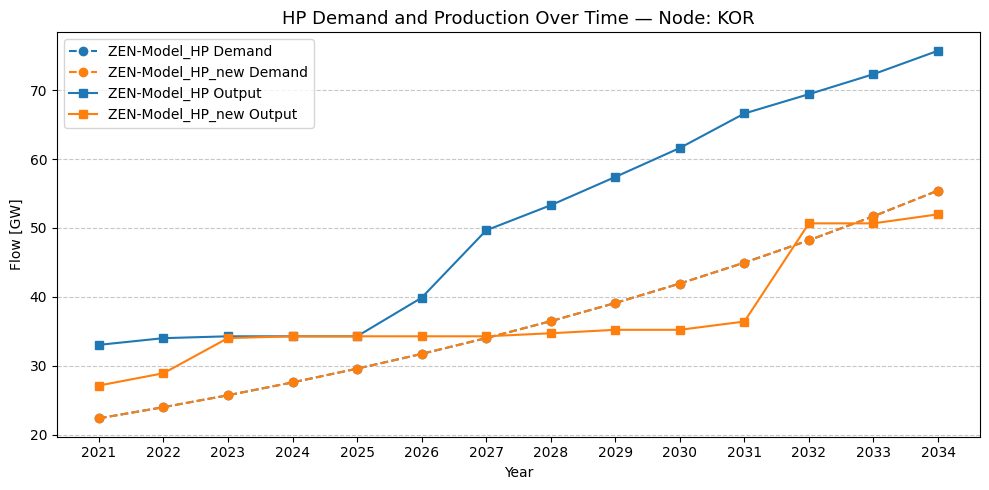

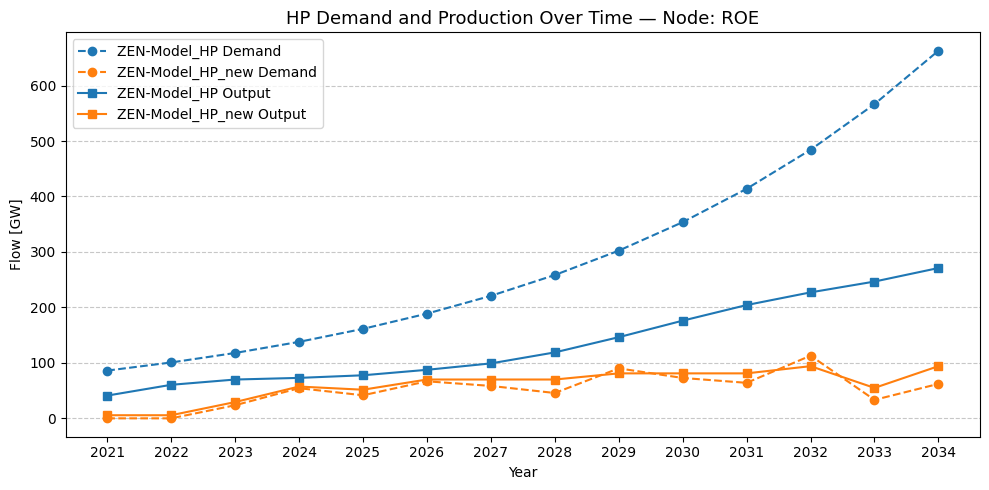

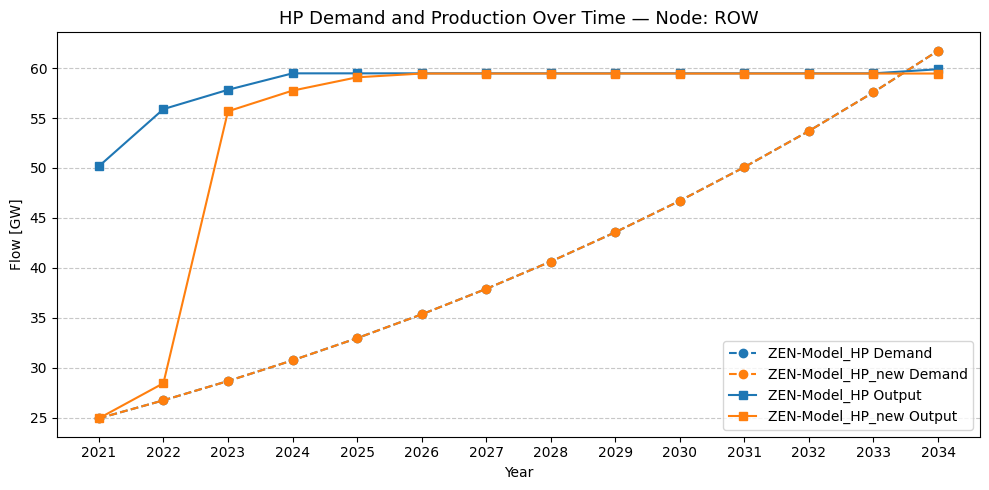

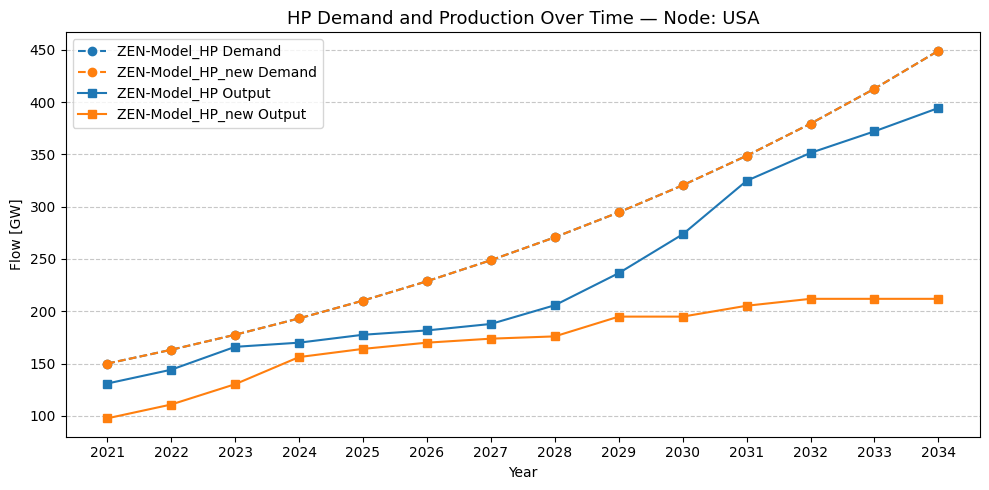

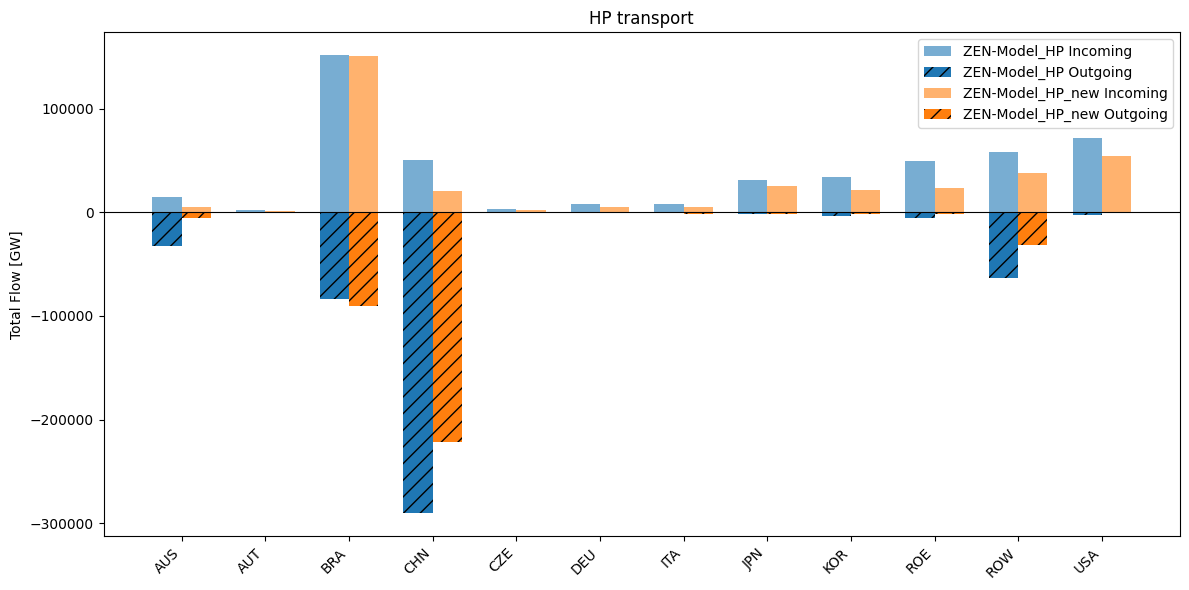

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'
technology_filter = "HP_assembly"
carrier_filter = "HP"

r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# === Save Paths ===
save_plots = True
save_path = Path(
    r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\SCM_plots\HP_device_analysis")
csv_export_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\device_demand_data")
os.makedirs(save_path, exist_ok=True)
os.makedirs(csv_export_path, exist_ok=True)

# === Style Settings ===
start_year = 2021
marker_styles = {dataset_name_1: 'o', dataset_name_2: 's'}
colors = {dataset_name_1: '#1f77b4', dataset_name_2: '#ff7f0e'}
linestyles = {dataset_name_1: '--', dataset_name_2: '-'}
line_widths = {dataset_name_1: 1.5, dataset_name_2: 1.5}


def plot_total_flow_per_node_hp_edge_based():
    var_name = "flow_transport"
    df1 = r1.get_full_ts(var_name).reset_index()
    df2 = r2.get_full_ts(var_name).reset_index()

    if "carrier" in df1.columns:
        df1 = df1[df1["carrier"] == carrier_filter]
    if "carrier" in df2.columns:
        df2 = df2[df2["carrier"] == carrier_filter]

    if "edge" not in df1.columns or "edge" not in df2.columns:
        print("❌ Edge column not found in flow_transport data.")
        return

    time_cols = [col for col in df1.columns if isinstance(col, (int, float))]
    df1["total_flow"] = df1[time_cols].sum(axis=1)
    df2["total_flow"] = df2[time_cols].sum(axis=1)

    def expand_edges(df):
        edge_split = df["edge"].str.split("-", expand=True)
        df["origin"] = edge_split[0]
        df["destination"] = edge_split[1]
        return df

    df1 = expand_edges(df1)
    df2 = expand_edges(df2)

    def get_node_flows(df):
        incoming = df.groupby("destination")["total_flow"].sum().rename("Incoming")
        outgoing = df.groupby("origin")["total_flow"].sum().rename("Outgoing")
        return pd.concat([incoming, outgoing], axis=1).fillna(0)

    combined1 = get_node_flows(df1)
    combined2 = get_node_flows(df2)
    all_nodes = sorted(set(combined1.index).union(combined2.index))

    width = 0.35
    x = range(len(all_nodes))
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar([i - width/2 for i in x], combined1.reindex(all_nodes)["Incoming"], width=width,
           label=f"{dataset_name_1} Incoming", color=colors[dataset_name_1], alpha=0.6)
    ax.bar([i - width/2 for i in x], -combined1.reindex(all_nodes)["Outgoing"], width=width,
           label=f"{dataset_name_1} Outgoing", color=colors[dataset_name_1], alpha=1.0, hatch='//')

    ax.bar([i + width/2 for i in x], combined2.reindex(all_nodes)["Incoming"], width=width,
           label=f"{dataset_name_2} Incoming", color=colors[dataset_name_2], alpha=0.6)
    ax.bar([i + width/2 for i in x], -combined2.reindex(all_nodes)["Outgoing"], width=width,
           label=f"{dataset_name_2} Outgoing", color=colors[dataset_name_2], alpha=1.0, hatch='//')

    ax.set_ylabel("Total Flow [GW]")
    ax.set_title(f"{carrier_filter} transport")
    ax.set_xticks(list(x))
    ax.set_xticklabels(all_nodes, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()
    plt.tight_layout()

    if save_plots:
        plt.savefig(save_path / f"{var_name}_{carrier_filter}_edge_inout_nodes.pdf", format='pdf', bbox_inches='tight')
    plt.show()


def plot_hp_demand_vs_conversion_output():
    var_demand = "demand"
    var_conversion = "flow_conversion_output"

    # Load and rename scenario column
    df1_d = r1.get_full_ts(var_demand).reset_index().rename(columns={"level_0": "scenario"})
    df2_d = r2.get_full_ts(var_demand).reset_index().rename(columns={"level_0": "scenario"})
    df1_d = df1_d[(df1_d["carrier"] == carrier_filter) & (df1_d["scenario"] == "scenario_")]
    df2_d = df2_d[(df2_d["carrier"] == carrier_filter) & (df2_d["scenario"] == "scenario_")]

    df1_c = r1.get_full_ts(var_conversion).reset_index().rename(columns={"level_0": "scenario"})
    df2_c = r2.get_full_ts(var_conversion).reset_index().rename(columns={"level_0": "scenario"})
    df1_c = df1_c[(df1_c["technology"] == technology_filter) & (df1_c["scenario"] == "scenario_")]
    df2_c = df2_c[(df2_c["technology"] == technology_filter) & (df2_c["scenario"] == "scenario_")]

    time_cols = [col for col in df1_d.columns if isinstance(col, (int, float))]

    df1_d["total_demand"] = df1_d[time_cols].sum(axis=1)
    df2_d["total_demand"] = df2_d[time_cols].sum(axis=1)
    df1_c["total_output"] = df1_c[time_cols].sum(axis=1)
    df2_c["total_output"] = df2_c[time_cols].sum(axis=1)

    demand1 = df1_d.groupby("node")["total_demand"].sum().rename("Demand")
    demand2 = df2_d.groupby("node")["total_demand"].sum().rename("Demand")
    output1 = df1_c.groupby("node")["total_output"].sum().rename("Output")
    output2 = df2_c.groupby("node")["total_output"].sum().rename("Output")

    all_nodes = sorted(set(demand1.index).union(output1.index).union(demand2.index).union(output2.index))

    width = 0.2
    x = range(len(all_nodes))
    fig, ax = plt.subplots(figsize=(14, 6))

    demand1_vals = demand1.reindex(all_nodes).fillna(0)
    output1_vals = output1.reindex(all_nodes).fillna(0)
    demand2_vals = demand2.reindex(all_nodes).fillna(0)
    output2_vals = output2.reindex(all_nodes).fillna(0)

    ax.bar([i - width * 1.5 for i in x], demand1_vals, width=width,
           label=f"{dataset_name_1} Demand", color=colors[dataset_name_1], alpha=0.6)
    ax.bar([i - width * 0.5 for i in x], output1_vals, width=width,
           label=f"{dataset_name_1} Output", color=colors[dataset_name_1], alpha=1.0, hatch='//')

    ax.bar([i + width * 0.5 for i in x], demand2_vals, width=width,
           label=f"{dataset_name_2} Demand", color=colors[dataset_name_2], alpha=0.6)
    ax.bar([i + width * 1.5 for i in x], output2_vals, width=width,
           label=f"{dataset_name_2} Output", color=colors[dataset_name_2], alpha=1.0, hatch='//')

    ax.set_ylabel("Power [GW]")
    ax.set_title(f"{carrier_filter} Demand vs Production")
    ax.set_xticks(list(x))
    ax.set_xticklabels(all_nodes, rotation=45, ha='right')
    ax.legend(ncol=2)
    plt.tight_layout()

    if save_plots:
        for fmt in ['pdf', 'png']:
            plt.savefig(save_path / f"{carrier_filter}_demand_vs_output_by_node.{fmt}", format=fmt, dpi=300, bbox_inches='tight')
    plt.show()


def plot_hp_demand_output_timeseries_by_node():
    var_demand = "demand"
    var_output = "flow_conversion_output"

    df1_d = r1.get_full_ts(var_demand).reset_index()
    df2_d = r2.get_full_ts(var_demand).reset_index()
    df1_d = df1_d[df1_d["carrier"] == carrier_filter]
    df2_d = df2_d[df2_d["carrier"] == carrier_filter]

    df1_o = r1.get_full_ts(var_output).reset_index()
    df2_o = r2.get_full_ts(var_output).reset_index()
    df1_o = df1_o[df1_o["technology"] == technology_filter]
    df2_o = df2_o[df2_o["technology"] == technology_filter]

    time_cols = [col for col in df1_d.columns if isinstance(col, (int, float))]

    # Group by node and keep full timeseries
    d1_grouped = df1_d.groupby("node")[time_cols].sum()
    d2_grouped = df2_d.groupby("node")[time_cols].sum()
    o1_grouped = df1_o.groupby("node")[time_cols].sum()
    o2_grouped = df2_o.groupby("node")[time_cols].sum()

    all_nodes = sorted(set(d1_grouped.index).union(d2_grouped.index).union(o1_grouped.index).union(o2_grouped.index))

    for node in all_nodes:
        if (
            d1_grouped.loc[node].sum() == 0 and d2_grouped.loc[node].sum() == 0 and
            o1_grouped.loc[node].sum() == 0 and o2_grouped.loc[node].sum() == 0
        ):
            continue  # skip empty nodes

        plt.figure(figsize=(10, 5))

        # Plot demand
        if node in d1_grouped.index:
            plt.plot(time_cols, d1_grouped.loc[node], label=f"{dataset_name_1} Demand",
                     color=colors[dataset_name_1], linestyle='--', marker='o')
        if node in d2_grouped.index:
            plt.plot(time_cols, d2_grouped.loc[node], label=f"{dataset_name_2} Demand",
                     color=colors[dataset_name_2], linestyle='--', marker='o')

        # Plot output
        if node in o1_grouped.index:
            plt.plot(time_cols, o1_grouped.loc[node], label=f"{dataset_name_1} Output",
                     color=colors[dataset_name_1], linestyle='-', marker='s')
        if node in o2_grouped.index:
            plt.plot(time_cols, o2_grouped.loc[node], label=f"{dataset_name_2} Output",
                     color=colors[dataset_name_2], linestyle='-', marker='s')

        plt.title(f"{carrier_filter} Demand and Production Over Time — Node: {node}", fontsize=13)
        plt.xlabel("Year")
        plt.ylabel("Flow [GW]")
        plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()

        if save_plots:
            plt.savefig(save_path / f"{carrier_filter}_demand_output_timeseries_{node}.pdf", format='pdf', bbox_inches='tight')

        plt.show()


# === Run All Plots ===
plot_hp_demand_vs_conversion_output()

plot_hp_demand_output_timeseries_by_node()
plot_total_flow_per_node_hp_edge_based()
